In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import geopandas as gpd
import folium

In [59]:
from google.colab import files

uploaded = files.upload()


Saving Elevage.csv to Elevage (1).csv
Saving Abattoirs.csv to Abattoirs (1).csv
Saving Pisciculture.csv to Pisciculture (1).csv
Saving retenue-eau.csv to retenue-eau (1).csv
Saving barrages.csv to barrages (1).csv
Saving agriculture-and-rural-tgo.csv to agriculture-and-rural-tgo (1).csv
Saving agriculture-sylviculture.csv to agriculture-sylviculture (1).csv
Saving agriculture-croissance-annuelle-.csv to agriculture-croissance-annuelle- (1).csv
Saving agriculture-sylviculture-et-peche-valeur-ajoutee-par-travailleur-en-dollars-constants-de-2015-.csv to agriculture-sylviculture-et-peche-valeur-ajoutee-par-travailleur-en-dollars-constants-de-2015- (1).csv
Saving agriculture-sylviculture-et-peche-valeur-ajoutee-en-dollars-us-constants-de-2015-.csv to agriculture-sylviculture-et-peche-valeur-ajoutee-en-dollars-us-constants-de-2015- (1).csv


In [60]:
abattoir = pd.read_csv("Abattoirs.csv")
barrages = pd.read_csv("barrages.csv")
pisciculture = pd.read_csv("Pisciculture.csv")
elevage = pd.read_csv("Elevage.csv")
retenue = pd.read_csv("retenue-eau.csv")

In [61]:
def nettoyer_colonnes(df):
    df.columns = df.columns.str.replace('_nom_bdd', '', regex=False)
    return df

# Appliquer à tous les fichiers
retenue = nettoyer_colonnes(retenue)
abattoir = nettoyer_colonnes(abattoir)
barrages = nettoyer_colonnes(barrages)
pisciculture = nettoyer_colonnes(pisciculture)
elevage = nettoyer_colonnes(elevage)

# Vérification rapide
for nom, df in [('retenue', retenue), ('abattoir', abattoir), ('barrages', barrages),
                 ('pisciculture', pisciculture), ('elevage', elevage)]:
    print(f"--- {nom} ---")
    print(df.columns.tolist())
    print()

--- retenue ---
['FID', 'region', 'prefecture', 'commune', 'canton', 'village', 'barrage_nom_officiel', 'barrage_type', 'barrage_utilisation', 'geometry']

--- abattoir ---
['FID', 'region', 'prefecture', 'commune', 'canton', 'abattoir_nom', 'abattoir_type', 'organisme', 'batiment_fonction', 'geometry']

--- barrages ---
['FID', 'region', 'prefecture', 'commune', 'canton', 'geometry']

--- pisciculture ---
['FID', 'region', 'prefecture', 'commune', 'canton', 'etab_adr', 'ouverture_jour', 'organisme', 'geometry']

--- elevage ---
['FID', 'region', 'prefecture', 'commune', 'canton', 'nom_localite', 'etab_nom', 'etab_adresse', 'etab_jour', 'etab_creation_date', 'activite_statut', 'activite_categorie', 'toilette_type', 'geometry']



In [62]:
# Vérifier rapidement chaque fichier
#abattoir.head()
#barrages.head()
#pisciculture.head()
#elevage.head()
retenue.head()



,FID,region,prefecture,commune,canton,village,barrage_nom_officiel,barrage_type,barrage_utilisation,geometry
0,_mview_general_retenues_eau_collinaires.fid--1...,Maritime,Avé,Avé 1,Ando,Adekpui,Nsp,Retenue d'eau,{autre},"MULTIPOLYGON (((0.80575 6.478061666666667, 0.8..."
1,_mview_general_retenues_eau_collinaires.fid--1...,Maritime,Avé,Avé 1,Kévé,Seve-kpota,Nsp,Retenue d'eau,"{elevage,irrigation}",MULTIPOLYGON (((0.9621006450743023 6.434965844...
2,_mview_general_retenues_eau_collinaires.fid--1...,Maritime,Golfe,Golfe 4,Amoutivé,Nyekonakpoé,Barrage Togbato de Nyekonakpoé,Retenue d'eau,"{irrigation,elevage}",MULTIPOLYGON (((1.1997724007862218 6.135243965...
3,_mview_general_retenues_eau_collinaires.fid--1...,Savanes,Oti,Oti 2,Galangashie,Nagouni,N/a,Mare naturelle,{autre},MULTIPOLYGON (((0.2226334859921552 10.41460408...
4,_mview_general_retenues_eau_collinaires.fid--1...,Maritime,Zio,Zio 4,Gapé-Centre,Lome5,Nsp,Retenue d'eau,"{elevage,autre}",MULTIPOLYGON (((1.1322133333333333 6.559738333...


In [63]:
# Avoir des infos sur les colonnes
#abattoir.info()
#barrages.info()
#pisciculture.info()
#elevage.info()
retenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   FID                   611 non-null    object
 1   region                611 non-null    object
 2   prefecture            611 non-null    object
 3   commune               611 non-null    object
 4   canton                611 non-null    object
 5   village               611 non-null    object
 6   barrage_nom_officiel  611 non-null    object
 7   barrage_type          611 non-null    object
 8   barrage_utilisation   611 non-null    object
 9   geometry              611 non-null    object
dtypes: object(10)
memory usage: 47.9+ KB


In [64]:
#
#retenue.describe()
#barrages.describe()
#abattoir.describe()
#elevage.describe()
pisciculture.describe()
#


,FID,region,prefecture,commune,canton,etab_adr,ouverture_jour,organisme,geometry
count,141,141,141,141,141,141,141,141,141
unique,141,5,25,48,72,89,29,49,141
top,_mview_general_zones_pisiculture.fid--1dff44f2...,Maritime,Lacs,Lacs 3,Agbodrafo,Néant,"{Lundi,Mardi,Mercredi,Jeudi,Vendredi,Samedi,Di...",Nsp,MULTIPOLYGON (((1.0315376399628242 6.464629891...
freq,1,78,30,12,8,39,86,42,1


In [65]:
#
barrages.isnull().sum()

,0
FID,0
region,0
prefecture,0
commune,0
canton,0
geometry,0


In [66]:
#
abattoir.isnull().sum()

,0
FID,0
region,0
prefecture,0
commune,0
canton,0
abattoir_nom,0
abattoir_type,0
organisme,0
batiment_fonction,0
geometry,0


In [67]:
#
pisciculture.isnull().sum()

,0
FID,0
region,0
prefecture,0
commune,0
canton,0
etab_adr,0
ouverture_jour,0
organisme,0
geometry,0


In [68]:
#
elevage.isnull().sum()

,0
FID,0
region,0
prefecture,0
commune,0
canton,0
nom_localite,0
etab_nom,0
etab_adresse,0
etab_jour,0
etab_creation_date,0


In [69]:
#
retenue.isnull().sum()

,0
FID,0
region,0
prefecture,0
commune,0
canton,0
village,0
barrage_nom_officiel,0
barrage_type,0
barrage_utilisation,0
geometry,0


In [70]:
#
print(retenue.shape)

(611, 10)


In [71]:
#
retenue.duplicated(subset=['village', 'canton']).sum()


np.int64(123)

In [72]:
#
# Nombre de retenues par région
#retenue['region'].value_counts()
#abattoir['region'].value_counts()
#elevage['region'].value_counts()
#pisciculture['region'].value_counts()
barrages['region'].value_counts()


,count
region,
Plateaux,90
Kara,69
Savanes,66
Maritime,48
Centrale,27


In [73]:
#
# Nombre de retenues par préfecture
barrages.groupby(['region', 'prefecture']).size().sort_values(ascending=False)

region    prefecture    
Savanes   Tône              40
Plateaux  Agou              37
Maritime  Zio               33
Plateaux  Haho              30
Kara      Dankpen           22
          Bassar            14
          Doufelgou         11
          Kéran             11
Savanes   Tandjoaré         10
Centrale  Blitta            10
Kara      Kozah              9
Maritime  Avé                8
Centrale  Sotouboua          7
Plateaux  Amou               5
Savanes   Kpendjal-Ouest     5
Centrale  Tchaoudjo          4
          Tchamba            4
Maritime  Lacs               4
Plateaux  Kloto              4
Savanes   Oti-Sud            4
          Cinkassé           3
Plateaux  Est-Mono           3
          Kpélé              3
Savanes   Oti                3
Centrale  Mô                 2
Kara      Assoli             2
Plateaux  Ogou               2
          Moyen-Mono         2
Maritime  Agoè-Nyivé         2
Plateaux  Anié               2
          Akébou             1
Maritime  Golfe              1
Plateaux  Danyi              1
Savanes   Kpendjal           1
dtype: int64

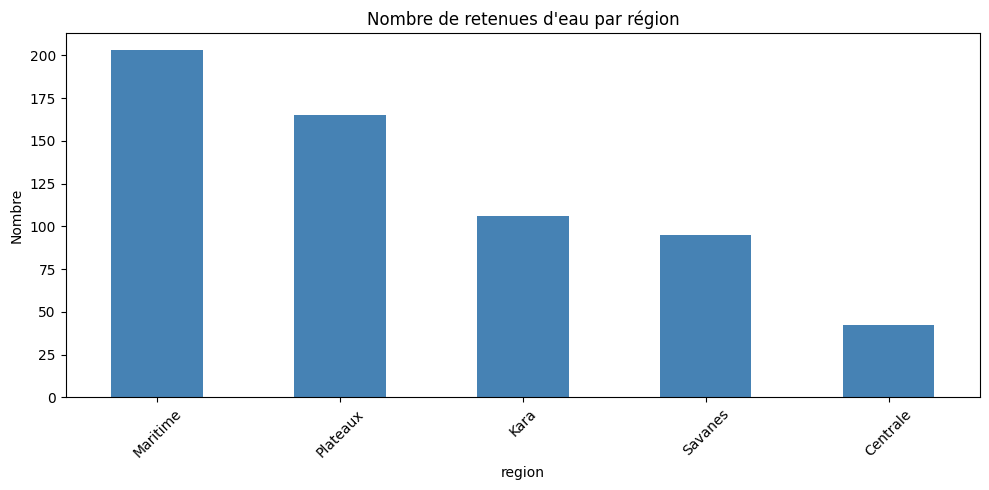

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
retenue['region'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Nombre de retenues d'eau par région")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

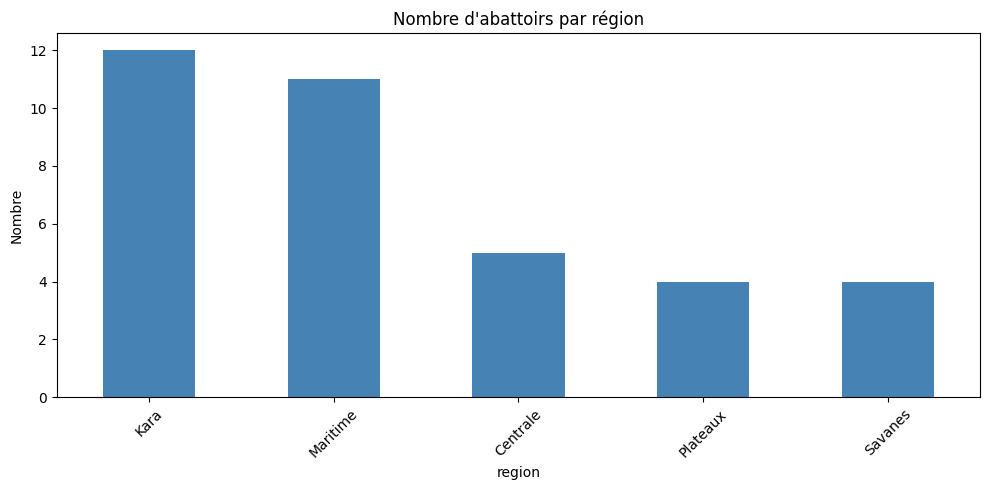

In [75]:
#
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
abattoir['region'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Nombre d'abattoirs par région")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#

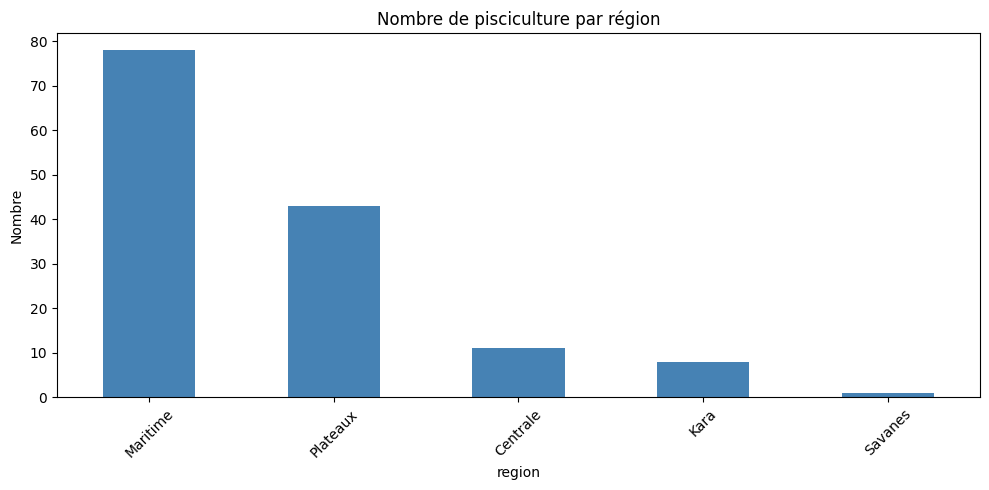

In [76]:
#
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
pisciculture['region'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Nombre de pisciculture par région")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

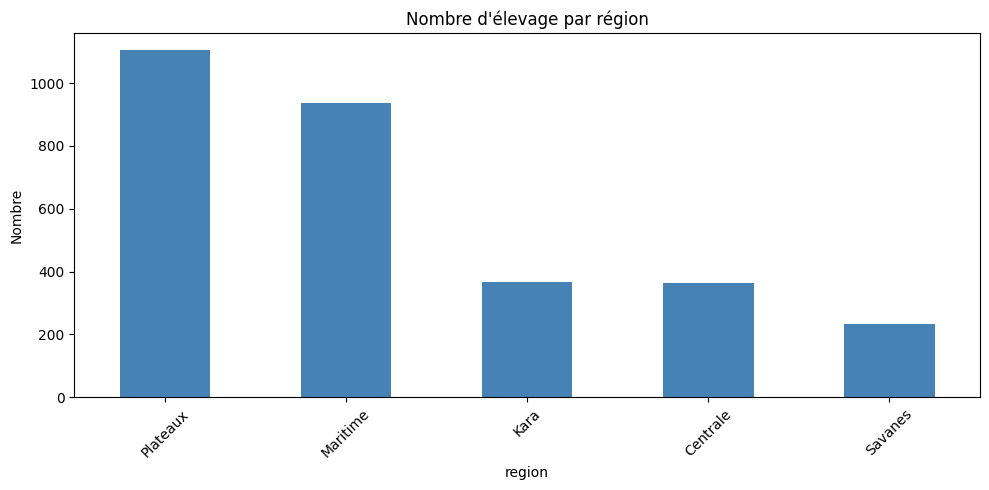

In [77]:
#
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
elevage['region'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Nombre d'élevage par région")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
print(type(retenue))

<class 'pandas.core.frame.DataFrame'>


In [79]:
print(retenue['geometry'].head())
print(type(retenue['geometry'].iloc[0]))

0    MULTIPOLYGON (((0.80575 6.478061666666667, 0.8...
1    MULTIPOLYGON (((0.9621006450743023 6.434965844...
2    MULTIPOLYGON (((1.1997724007862218 6.135243965...
3    MULTIPOLYGON (((0.2226334859921552 10.41460408...
4    MULTIPOLYGON (((1.1322133333333333 6.559738333...
Name: geometry, dtype: object
<class 'str'>


In [80]:
import geopandas as gpd
from shapely import wkt
from shapely.validation import make_valid
from shapely.geometry.base import BaseGeometry
import folium
import requests

# Vérifier l'état actuel AVANT conversion
print("Type de la colonne geometry :", type(retenue['geometry'].iloc[0]))

# Conversion sécurisée (fonctionne peu importe l'état actuel)
def convertir_geometry(val):
    if isinstance(val, BaseGeometry):
        return val
    return wkt.loads(val)

retenue['geometry'] = retenue['geometry'].apply(convertir_geometry)
retenue = gpd.GeoDataFrame(retenue, geometry='geometry', crs='EPSG:4326')
retenue['geometry'] = retenue['geometry'].apply(make_valid)

print("OK, conversion réussie")
print(retenue.geom_type.value_counts())



Type de la colonne geometry : <class 'str'>
OK, conversion réussie
MultiPolygon          603
Polygon                 7
GeometryCollection      1
Name: count, dtype: int64


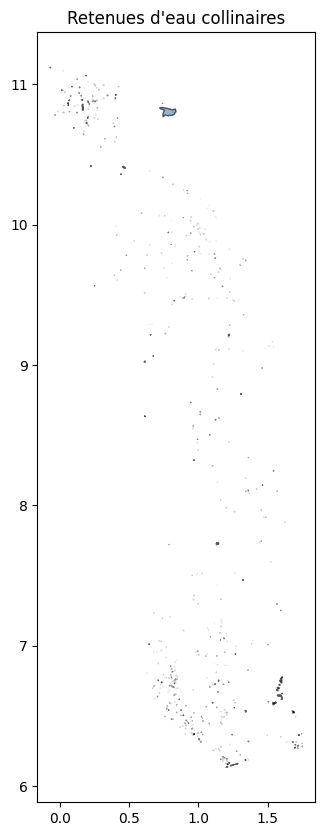

In [81]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
retenue.plot(ax=ax, color='steelblue', edgecolor='black', alpha=0.6)
ax.set_title("Retenues d'eau collinaires")
plt.show()

In [82]:
import folium
import requests

# --- Centrer la carte ---
minx, miny, maxx, maxy = retenue.total_bounds
centre_lat = (miny + maxy) / 2
centre_lon = (minx + maxx) / 2

m = folium.Map(location=[centre_lat, centre_lon], zoom_start=8)

# --- Contour du Togo ---
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/TGO.geo.json"
togo_geojson = requests.get(url).json()

folium.GeoJson(
    togo_geojson,
    name='Togo',
    style_function=lambda x: {'fillColor': 'none', 'color': 'red', 'weight': 2}
).add_to(m)

# --- Les retenues d'eau ---
folium.GeoJson(
    retenue,
    name="Retenues d'eau",
    style_function=lambda x: {
        'fillColor': 'steelblue',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.5
    },
    tooltip=folium.GeoJsonTooltip(fields=['village', 'region'], aliases=['Village:', 'Région:'])
).add_to(m)

folium.LayerControl().add_to(m)
m

/usr/local/lib/python3.12/dist-packages/folium/features.py:1204: UserWarning: GeoJsonTooltip is not configured to render for GeoJson GeometryCollection geometries. Please consider reworking these features: [{'FID': '_mview_general_retenues_eau_collinaires.fid--1dff44f2_19f23bc4a0d_-3503', 'region': 'Kara', 'prefecture': 'Bassar', 'commune': 'Bassar 1', 'canton': 'Kalanga', 'village': 'Boungba', 'barrage_nom_officiel': 'Nsp', 'barrage_type': "Retenue d'eau", 'barrage_utilisation': '{irrigation}'}] to MultiPolygon for full functionality.
https://tools.ietf.org/html/rfc7946#page-9
  warnings.warn(


In [83]:
# Indice de résilience agricole
import pandas as pd

# Compter les infrastructures par canton pour chaque fichier
compte_retenue = retenue.groupby('canton').size().rename('nb_retenue')
compte_barrages = barrages.groupby('canton').size().rename('nb_barrages')
compte_elevage = elevage.groupby('canton').size().rename('nb_elevage')
compte_pisciculture = pisciculture.groupby('canton').size().rename('nb_pisciculture')
compte_abattoir = abattoir.groupby('canton').size().rename('nb_abattoir')

# Fusionner tout, avec la liste complète des cantons (union des 4 sources)
irat = pd.concat([compte_retenue,compte_barrages, compte_elevage, compte_pisciculture, compte_abattoir], axis=1)
irat = irat.fillna(0)  # un canton absent d'un fichier = 0 infrastructure de ce type

#calcul nb_eau
irat['nb_eau'] = irat['nb_retenue'] + irat['nb_barrages']

# Supprimer les colonnes inutiles
irat = irat.drop(columns=['nb_retenue', 'nb_barrages'])

# Récupérer aussi la préfecture/région de chaque canton (pour l'agrégation plus tard)
# On prend la correspondance depuis un des fichiers qui a canton + prefecture
correspondance = retenue[['canton', 'prefecture', 'region']].drop_duplicates(subset='canton')
irat = irat.merge(correspondance, left_index=True, right_on='canton', how='left')

irat.head()


,nb_elevage,nb_pisciculture,nb_abattoir,nb_eau,canton,prefecture,region
164.0,8.0,1.0,0.0,2.0,Abobo,Zio,Maritime
307.0,1.0,0.0,0.0,1.0,Adiva,Amou,Plateaux
393.0,12.0,0.0,0.0,4.0,Adjengré,Sotouboua,Centrale
303.0,2.0,0.0,0.0,3.0,Adogbénou,Anié,Plateaux
12.0,7.0,0.0,0.0,2.0,Adétikopé,Agoè-Nyivé,Maritime


In [84]:
#
# Construire la correspondance à partir de TOUS les fichiers (pas juste retenue)
correspondance = pd.concat([
    barrages[['canton', 'prefecture', 'region']],
    retenue[['canton', 'prefecture', 'region']],
    abattoir[['canton', 'prefecture', 'region']],
    pisciculture[['canton', 'prefecture', 'region']],
    elevage[['canton', 'prefecture', 'region']],
]).drop_duplicates(subset='canton')

print("Nb de correspondances canton uniques:", len(correspondance))

# Refaire le merge sur irat (en supprimant d'abord les anciennes colonnes prefecture/region)
irat = irat.drop(columns=['prefecture', 'region'])
irat = irat.merge(correspondance, left_on='canton', right_on='canton', how='left')

# Revérifier les orphelins
print("Cantons sans préfecture:", irat['prefecture'].isna().sum())
print("Cantons sans région:", irat['region'].isna().sum())

Nb de correspondances canton uniques: 363
Cantons sans préfecture: 0
Cantons sans région: 0


In [85]:
# Calcul de l'IRAT
import numpy as np

# --- 1. Normalisation 0-100 de chaque composante ---
def normaliser(serie):
    if serie.max() == serie.min():
        return pd.Series(50, index=serie.index)
    return (serie - serie.min()) / (serie.max() - serie.min()) * 100


# --- 2. Indice de diversité (Performance) ---
def indice_diversite(row):
    valeurs = np.array([row['nb_eau'], row['nb_elevage'], row['nb_pisciculture'], row['nb_abattoir']])
    total = valeurs.sum()
    if total == 0:
        return 0
    proportions = valeurs / total
    proportions = proportions[proportions > 0]
    entropie = -np.sum(proportions * np.log(proportions))
    entropie_max = np.log(4)
    return (entropie / entropie_max) * 100

irat['score_performance'] = irat.apply(indice_diversite, axis=1)


irat['score_eau'] = normaliser(irat['nb_eau'])
irat['score_elevage'] = normaliser(irat['nb_elevage'])
irat['score_pisciculture'] = normaliser(irat['nb_pisciculture'])
irat['score_abattoir'] = normaliser(irat['nb_abattoir'])
irat['score_performance'] = irat.apply(indice_diversite, axis=1)

irat['IRAT'] = (
    0.30 * irat['score_eau'] +
    0.25 * irat['score_elevage'] +
    0.20 * irat['score_pisciculture'] +
    0.15 * irat['score_abattoir'] +
    0.10 * irat['score_performance']
)

irat_sorted = irat.sort_values('IRAT', ascending=False)
irat_sorted[['canton', 'prefecture', 'region', 'IRAT']].head(10)



,canton,prefecture,region,IRAT
70,Gadja,Agou,Plateaux,54.749260
201,Agbodrafo,Lacs,Maritime,37.256437
23,Amoussou-Kopé,Agou,Plateaux,33.776118
190,Wahala,Haho,Plateaux,32.810448
186,Tsévié,Zio,Maritime,30.592801
72,Gamé-Sèva,Zio,Maritime,29.774964
53,Bè-Ouest,Golfe,Maritime,28.094502
40,Baguida,Golfe,Maritime,27.787042
9,Agotimé-Nord,Agou,Plateaux,26.394059
52,Bè-Est,Golfe,Maritime,25.362335


In [86]:
# Agrégation par préfecture
# Recalcul direct des totaux au niveau préfecture (plus rigoureux qu'une moyenne de scores cantons)
irat_prefecture = irat.groupby(['prefecture', 'region'])[['nb_eau', 'nb_elevage', 'nb_pisciculture', 'nb_abattoir']].sum().reset_index()

irat_prefecture['score_eau'] = normaliser(irat_prefecture['nb_eau'])
irat_prefecture['score_elevage'] = normaliser(irat_prefecture['nb_elevage'])
irat_prefecture['score_pisciculture'] = normaliser(irat_prefecture['nb_pisciculture'])
irat_prefecture['score_abattoir'] = normaliser(irat_prefecture['nb_abattoir'])
irat_prefecture['score_performance'] = irat_prefecture.apply(indice_diversite, axis=1)

irat_prefecture['IRAT'] = (
    0.30 * irat_prefecture['score_eau'] +
    0.25 * irat_prefecture['score_elevage'] +
    0.20 * irat_prefecture['score_pisciculture'] +
    0.15 * irat_prefecture['score_abattoir'] +
    0.10 * irat_prefecture['score_performance']
)

irat_prefecture_sorted = irat_prefecture.sort_values('IRAT', ascending=False)
irat_prefecture_sorted[['prefecture', 'region', 'IRAT']]

,prefecture,region,IRAT
0,Agou,Plateaux,56.391160
38,Zio,Maritime,55.591669
17,Haho,Plateaux,50.233207
24,Lacs,Maritime,44.228443
6,Avé,Maritime,43.084320
16,Golfe,Maritime,40.206409
34,Tône,Savanes,33.096946
8,Bassar,Kara,32.287173
19,Kozah,Kara,26.700842
14,Doufelgou,Kara,23.915103


In [87]:
#
# Seuil : cantons dans le quartile le plus faible (25% les plus vulnérables)
seuil_vulnerable = irat['IRAT'].quantile(0.25)

cantons_vulnerables = irat[irat['IRAT'] <= seuil_vulnerable].sort_values('IRAT')

print(f"Seuil de vulnérabilité (Q1) : {seuil_vulnerable:.2f}")
print(f"Nombre de cantons vulnérables : {len(cantons_vulnerables)}")
cantons_vulnerables[['canton', 'prefecture', 'region', 'IRAT']].head(15)

Seuil de vulnérabilité (Q1) : 0.89
Nombre de cantons vulnérables : 102


,canton,prefecture,region,IRAT
217,Amoussimé,Yoto,Maritime,0.14881
220,Aného,Lacs,Maritime,0.14881
235,Boulogou,Tandjoaré,Savanes,0.14881
291,Kpélé-Centre,Kpélé,Plateaux,0.14881
280,Koumondè,Assoli,Kara,0.14881
281,Kouméa,Kozah,Kara,0.14881
261,Gobé,Wawa,Plateaux,0.14881
255,Gbadi-N'kougna,Wawa,Plateaux,0.14881
308,Mamproug,Tandjoaré,Savanes,0.14881
289,Kpassaouade,Tchaoudjo,Centrale,0.14881


In [88]:
# Top 10 zones d'investissement
# Score de "potentiel investissement" = vulnérabilité pondérée par une base existante minimale
irat['nb_infra_total'] = irat['nb_eau'] + irat['nb_elevage'] + irat['nb_pisciculture'] + irat['nb_abattoir']

# On exclut les cantons à 0 infrastructure totale (pas de base à développer, cas à part)
candidats = irat[irat['nb_infra_total'] > 0].copy()

# Score de priorité : plus l'IRAT est bas, plus la priorité est haute (on inverse l'échelle)
candidats['score_priorite'] = 100 - candidats['IRAT']

top10_investissement = candidats.sort_values('score_priorite', ascending=False)
top10_investissement[['canton', 'prefecture', 'region', 'IRAT', 'nb_infra_total', 'score_priorite']].head(10)

,canton,prefecture,region,IRAT,nb_infra_total,score_priorite
356,Yalla,Akébou,Plateaux,0.14881,1.0,99.85119
329,Soumdina,Kozah,Kara,0.14881,1.0,99.85119
324,Sanfatoute,Tône,Savanes,0.14881,1.0,99.85119
325,Sangou,Tandjoaré,Savanes,0.14881,1.0,99.85119
334,Tambonga,Kpendjal-Ouest,Savanes,0.14881,1.0,99.85119
326,Saïboudè,Mô,Centrale,0.14881,1.0,99.85119
220,Aného,Lacs,Maritime,0.14881,1.0,99.85119
217,Amoussimé,Yoto,Maritime,0.14881,1.0,99.85119
354,Womé,Kloto,Plateaux,0.14881,1.0,99.85119
255,Gbadi-N'kougna,Wawa,Plateaux,0.14881,1.0,99.85119


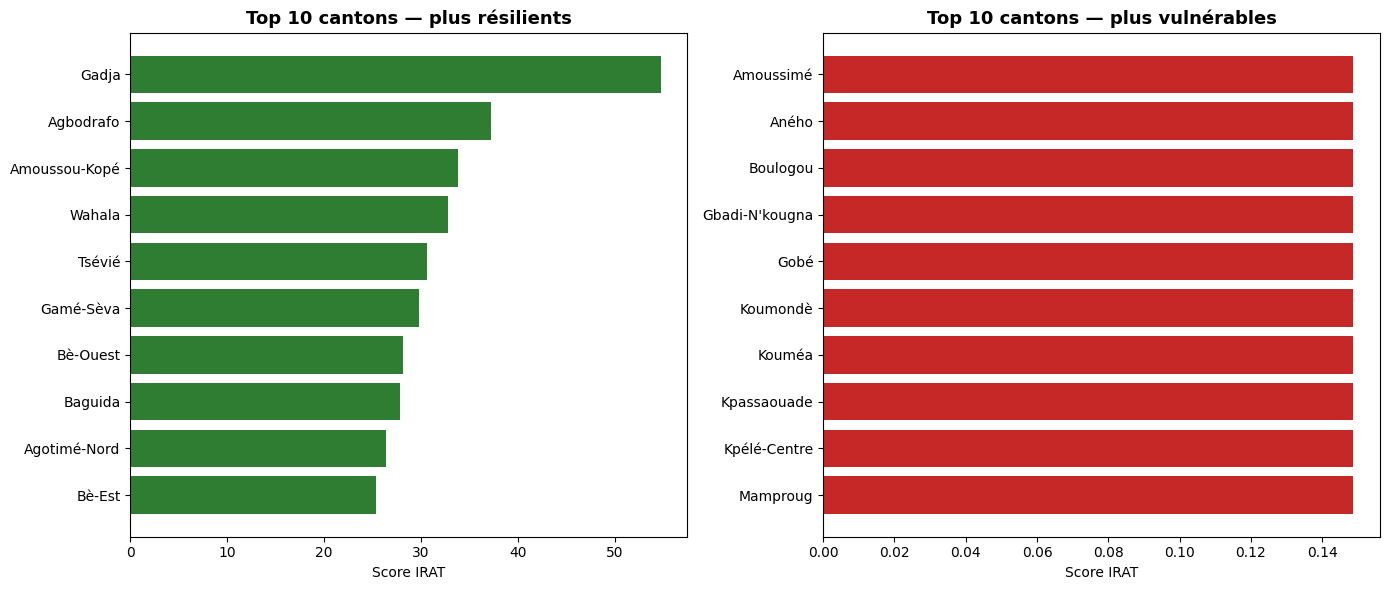

In [89]:
import matplotlib.pyplot as plt

top10 = irat.nlargest(10, 'IRAT')[['canton', 'IRAT']]
bottom10 = irat.nsmallest(10, 'IRAT')[['canton', 'IRAT']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10['canton'][::-1], top10['IRAT'][::-1], color='#2E7D32')
axes[0].set_title('Top 10 cantons — plus résilients', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score IRAT')

axes[1].barh(bottom10['canton'][::-1], bottom10['IRAT'][::-1], color='#C62828')
axes[1].set_title('Top 10 cantons — plus vulnérables', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score IRAT')

plt.tight_layout()
plt.show()

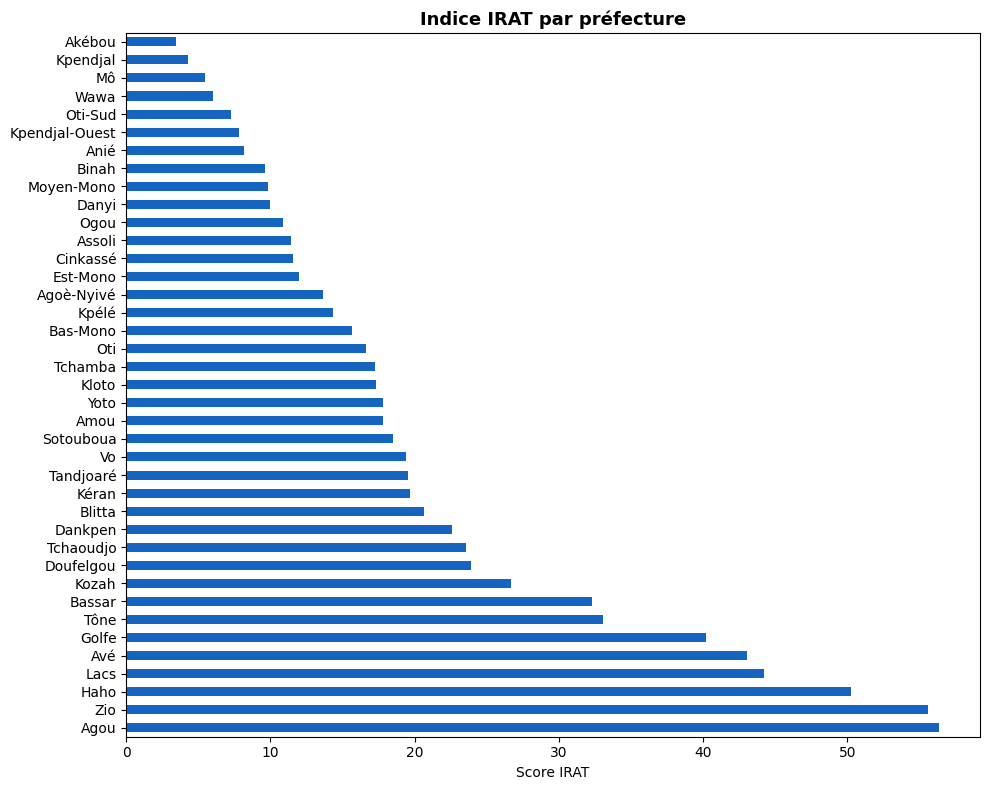

In [90]:
fig, ax = plt.subplots(figsize=(10, 8))
irat_prefecture_sorted.plot(x='prefecture', y='IRAT', kind='barh', ax=ax, color='#1565C0', legend=False)
ax.set_title("Indice IRAT par préfecture", fontsize=13, fontweight='bold')
ax.set_xlabel("Score IRAT")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

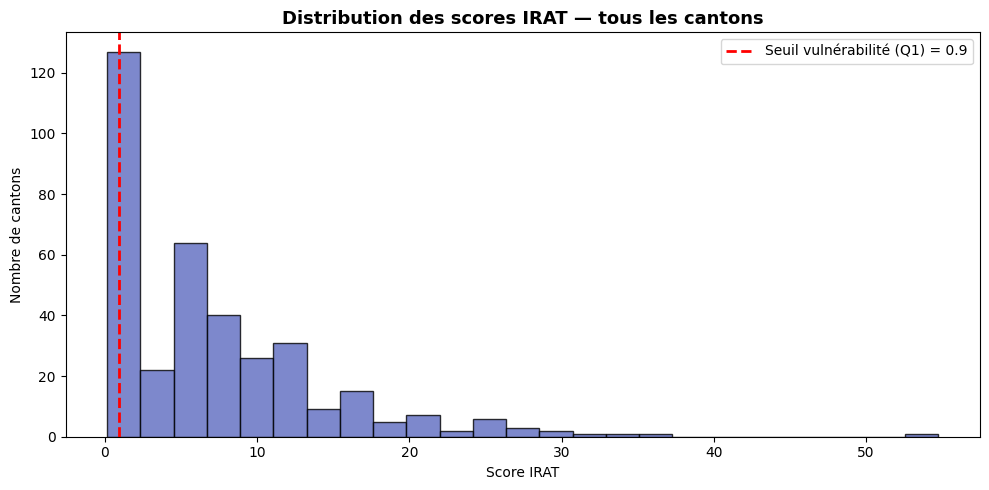

In [91]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(irat['IRAT'], bins=25, color='#5C6BC0', edgecolor='black', alpha=0.8)
ax.axvline(seuil_vulnerable, color='red', linestyle='--', linewidth=2, label=f'Seuil vulnérabilité (Q1) = {seuil_vulnerable:.1f}')
ax.set_title("Distribution des scores IRAT — tous les cantons", fontsize=13, fontweight='bold')
ax.set_xlabel("Score IRAT")
ax.set_ylabel("Nombre de cantons")
ax.legend()
plt.tight_layout()
plt.show()

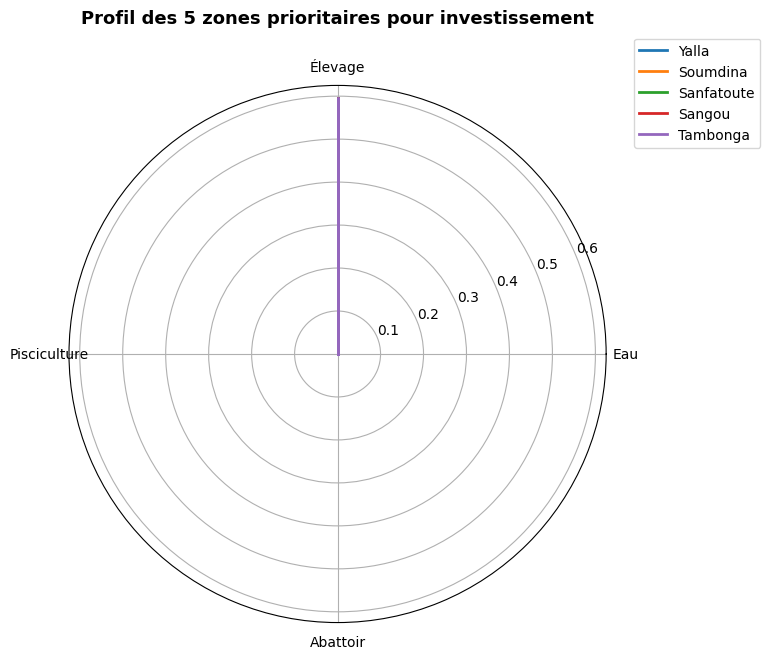

In [92]:
import numpy as np

top5_invest = top10_investissement.head(5)
categories = ['Eau', 'Élevage', 'Pisciculture', 'Abattoir']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for _, row in top5_invest.iterrows():
    valeurs = [row['score_eau'], row['score_elevage'], row['score_pisciculture'], row['score_abattoir']]
    valeurs += valeurs[:1]
    ax.plot(angles, valeurs, linewidth=2, label=row['canton'])
    ax.fill(angles, valeurs, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title("Profil des 5 zones prioritaires pour investissement", fontsize=13, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [93]:
import folium

# Fusionner le score IRAT avec la géométrie des cantons (via retenue, qui a les polygones)
geo_cantons = retenue[['canton', 'geometry']].drop_duplicates(subset='canton')
irat_geo = geo_cantons.merge(irat[['canton', 'IRAT']], on='canton', how='inner')
irat_geo = gpd.GeoDataFrame(irat_geo, geometry='geometry', crs='EPSG:4326')

minx, miny, maxx, maxy = irat_geo.total_bounds
m = folium.Map(location=[(miny+maxy)/2, (minx+maxx)/2], zoom_start=8)

folium.Choropleth(
    geo_data=irat_geo,
    data=irat_geo,
    columns=['canton', 'IRAT'],
    key_on='feature.properties.canton',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Score IRAT (résilience agricole)'
).add_to(m)

m

In [94]:
# S'assurer que nb_infra_total existe
irat['nb_infra_total'] = irat['nb_eau'] + irat['nb_elevage'] + irat['nb_pisciculture'] + irat['nb_abattoir']

# Moyenne pondérée de l'IRAT par préfecture
def moyenne_ponderee(groupe):
    poids = groupe['nb_infra_total']
    if poids.sum() == 0:
        return groupe['IRAT'].mean()  # cas où aucune infra, on fait une moyenne simple
    return np.average(groupe['IRAT'], weights=poids)

irat_prefecture = irat.groupby(['prefecture', 'region']).apply(
    lambda g: pd.Series({
        'IRAT': moyenne_ponderee(g),
        'nb_cantons': len(g),
        'nb_infra_total': g['nb_infra_total'].sum()
    })
).reset_index()

irat_prefecture_sorted = irat_prefecture.sort_values('IRAT', ascending=False)
irat_prefecture_sorted

/tmp/ipykernel_3632/146557365.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  irat_prefecture = irat.groupby(['prefecture', 'region']).apply(


,prefecture,region,IRAT,nb_cantons,nb_infra_total
0,Agou,Plateaux,30.267227,12.0,301.0
24,Lacs,Maritime,22.512599,10.0,157.0
17,Haho,Plateaux,22.483932,10.0,480.0
16,Golfe,Maritime,20.941624,7.0,258.0
38,Zio,Maritime,20.797761,16.0,321.0
6,Avé,Maritime,16.360008,9.0,243.0
35,Vo,Maritime,13.408150,8.0,82.0
10,Blitta,Centrale,12.695100,17.0,134.0
8,Bassar,Kara,11.862172,10.0,124.0
28,Oti,Savanes,11.255020,6.0,40.0


In [95]:
total_cantons = len(irat)
print(f"Nombre total de cantons : {total_cantons}")

# Test de plusieurs définitions de "vulnérable"
seuil_median = irat['IRAT'].median()
seuil_q1 = irat['IRAT'].quantile(0.25)
seuil_q1_33 = irat['IRAT'].quantile(0.33)
seuil_fixe_50 = 50

print(f"\n--- Sous la médiane ({seuil_median:.2f}) ---")
print("Nombre de cantons:", (irat['IRAT'] < seuil_median).sum())

print(f"\n--- Sous Q1 ({seuil_q1:.2f}) ---")
print("Nombre de cantons:", (irat['IRAT'] <= seuil_q1).sum())

print(f"\n--- Sous le 33e percentile ({seuil_q1_33:.2f}) ---")
print("Nombre de cantons:", (irat['IRAT'] <= seuil_q1_33).sum())

print(f"\n--- IRAT < 50 (seuil fixe) ---")
print("Nombre de cantons:", (irat['IRAT'] < seuil_fixe_50).sum())

Nombre total de cantons : 363

--- Sous la médiane (6.08) ---
Nombre de cantons: 181

--- Sous Q1 (0.89) ---
Nombre de cantons: 102

--- Sous le 33e percentile (1.29) ---
Nombre de cantons: 120

--- IRAT < 50 (seuil fixe) ---
Nombre de cantons: 362


In [96]:
print("Nombre total de cantons:", len(irat))
print("IRAT moyen:", irat['IRAT'].mean())
print("IRAT médian:", irat['IRAT'].median())

# Cantons sous la moyenne (différent de la médiane)
print("\nSous la moyenne:", (irat['IRAT'] < irat['IRAT'].mean()).sum())

# Chercher automatiquement le percentile qui donne 209 cantons
n_cible = 209
irat_sorted_asc = irat.sort_values('IRAT').reset_index(drop=True)
if n_cible <= len(irat_sorted_asc):
    valeur_a_209 = irat_sorted_asc.loc[n_cible - 1, 'IRAT']
    percentile_equivalent = (n_cible / len(irat)) * 100
    print(f"\nPour obtenir exactement {n_cible} cantons vulnérables :")
    print(f"Seuil IRAT correspondant : {valeur_a_209:.2f}")
    print(f"Cela représente le {percentile_equivalent:.1f}e percentile")

Nombre total de cantons: 363
IRAT moyen: 7.1299047065894
IRAT médian: 6.080200146105188

Sous la moyenne: 218

Pour obtenir exactement 209 cantons vulnérables :
Seuil IRAT correspondant : 6.55
Cela représente le 57.6e percentile


In [97]:
irat['vulnerable_score_bas'] = irat['IRAT'] < irat['IRAT'].mean()
irat['vulnerable_zero_eau'] = irat['nb_eau'] == 0
irat['vulnerable_zero_abattoir'] = irat['nb_abattoir'] == 0
irat['vulnerable_faible_diversite'] = irat['score_performance'] < irat['score_performance'].quantile(0.25)

irat['est_vulnerable'] = (
    irat['vulnerable_score_bas'] |
    irat['vulnerable_zero_eau'] |
    irat['vulnerable_zero_abattoir']
)

print("Nombre de cantons vulnérables (multi-critères):", irat['est_vulnerable'].sum())
print("\nDétail :")
print("- Score IRAT sous la moyenne:", irat['vulnerable_score_bas'].sum())
print("- Zéro accès à l'eau:", irat['vulnerable_zero_eau'].sum())
print("- Zéro abattoir:", irat['vulnerable_zero_abattoir'].sum())
print("- Faible diversité:", irat['vulnerable_faible_diversite'].sum())

Nombre de cantons vulnérables (multi-critères): 340

Détail :
- Score IRAT sous la moyenne: 218
- Zéro accès à l'eau: 167
- Zéro abattoir: 329
- Faible diversité: 0


           Type  Cantons avec 0  % sans accès  % avec accès
0           Eau             167          46.0          54.0
1       Élevage              23           6.3          93.7
2  Pisciculture             291          80.2          19.8
3      Abattoir             329          90.6           9.4


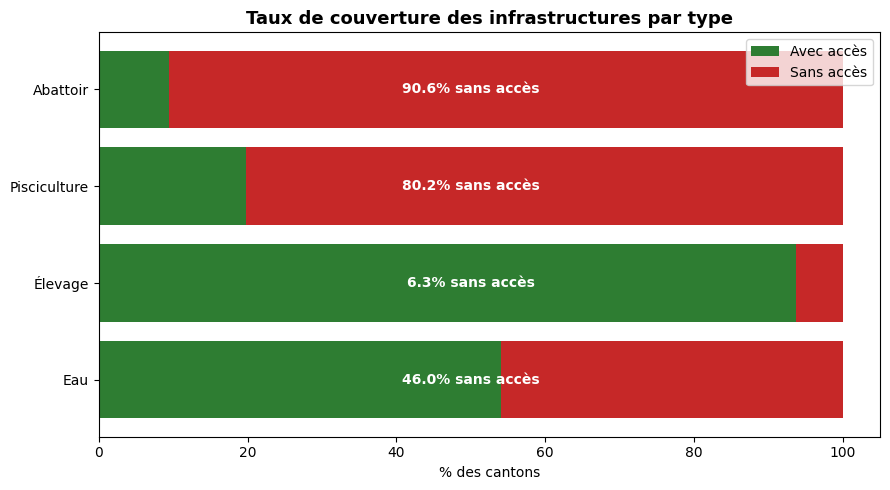

In [98]:
total_cantons = len(irat)

couverture = pd.DataFrame({
    'Type': ['Eau', 'Élevage', 'Pisciculture', 'Abattoir'],
    'Cantons avec 0': [
        (irat['nb_eau'] == 0).sum(),
        (irat['nb_elevage'] == 0).sum(),
        (irat['nb_pisciculture'] == 0).sum(),
        (irat['nb_abattoir'] == 0).sum(),
    ]
})
couverture['% sans accès'] = (couverture['Cantons avec 0'] / total_cantons * 100).round(1)
couverture['% avec accès'] = 100 - couverture['% sans accès']

print(couverture)

# Graphique
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(couverture['Type'], couverture['% avec accès'], color='#2E7D32', label='Avec accès')
ax.barh(couverture['Type'], couverture['% sans accès'], left=couverture['% avec accès'], color='#C62828', label='Sans accès')
ax.set_xlabel('% des cantons')
ax.set_title("Taux de couverture des infrastructures par type", fontsize=13, fontweight='bold')
ax.legend()
for i, row in couverture.iterrows():
    ax.text(50, i, f"{row['% sans accès']}% sans accès", va='center', ha='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

          IRAT moyen  Écart-type   Min    Max  Nb cantons
region                                                   
Maritime       11.00        8.78  0.15  37.26          75
Plateaux        6.72        8.23  0.15  54.75         105
Kara            6.80        5.71  0.15  24.30          71
Savanes         5.09        5.59  0.15  24.89          58
Centrale        5.17        5.39  0.15  21.94          54


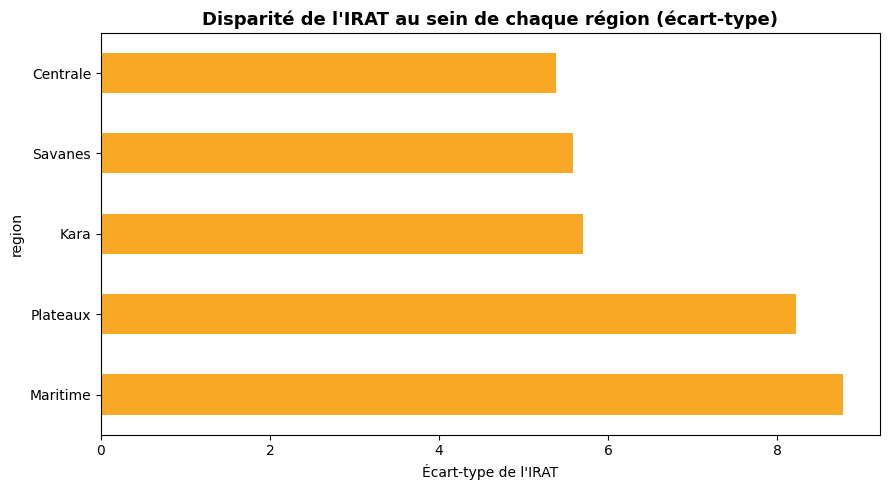

In [99]:
disparite_regionale = irat.groupby('region')['IRAT'].agg(['mean', 'std', 'min', 'max', 'count']).round(2)
disparite_regionale = disparite_regionale.sort_values('std', ascending=False)
disparite_regionale.columns = ['IRAT moyen', 'Écart-type', 'Min', 'Max', 'Nb cantons']
print(disparite_regionale)

fig, ax = plt.subplots(figsize=(9, 5))
disparite_regionale['Écart-type'].plot(kind='barh', ax=ax, color='#F9A825')
ax.set_title("Disparité de l'IRAT au sein de chaque région (écart-type)", fontsize=13, fontweight='bold')
ax.set_xlabel("Écart-type de l'IRAT")
plt.tight_layout()
plt.show()

In [100]:
print(abattoir.columns.tolist())
print(abattoir['geometry'].iloc[0] if 'geometry' in abattoir.columns else "Pas de colonne geometry")

['FID', 'region', 'prefecture', 'commune', 'canton', 'abattoir_nom', 'abattoir_type', 'organisme', 'batiment_fonction', 'geometry']
POINT (1.2078533333333332 6.254586666666667)


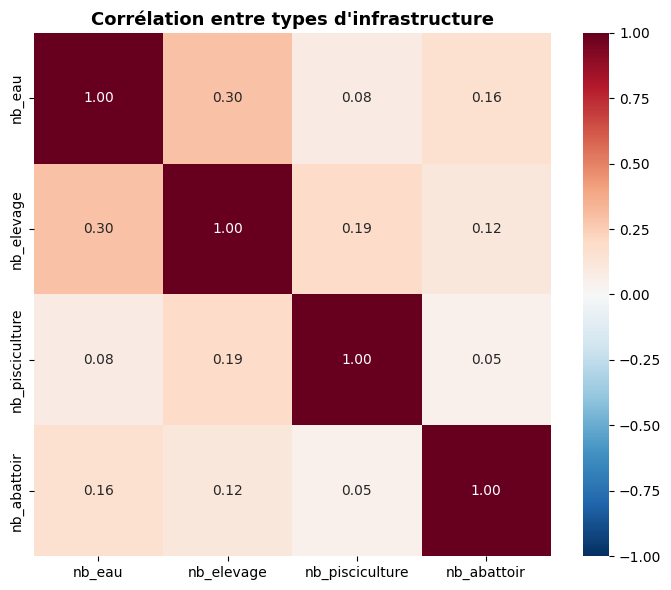

In [101]:
import seaborn as sns

correlation = irat[['nb_eau', 'nb_elevage', 'nb_pisciculture', 'nb_abattoir']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax, vmin=-1, vmax=1)
ax.set_title("Corrélation entre types d'infrastructure", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

categorie
Vulnérable avec base existante    340
Non vulnérable                     23
Name: count, dtype: int64


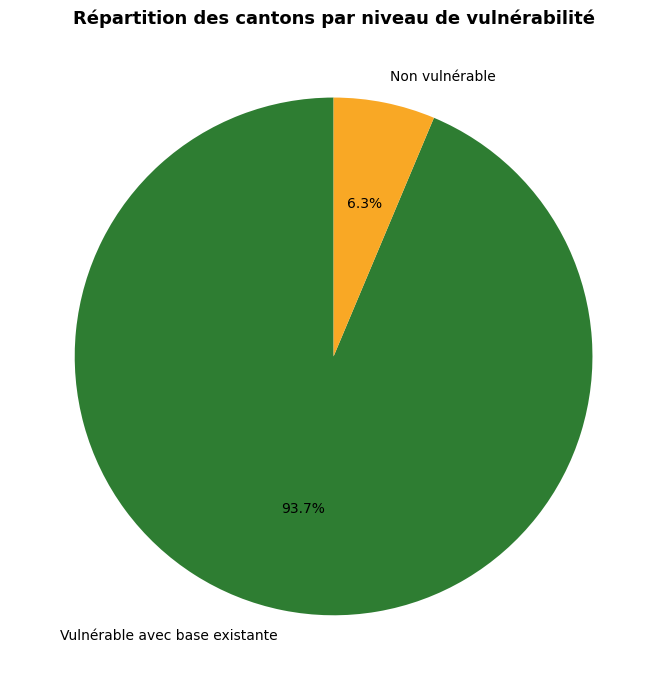

In [102]:
irat['categorie'] = 'Non vulnérable'
irat.loc[(irat['est_vulnerable']) & (irat['nb_infra_total'] > 0), 'categorie'] = 'Vulnérable avec base existante'
irat.loc[(irat['est_vulnerable']) & (irat['nb_infra_total'] == 0), 'categorie'] = 'Vulnérable sans aucune base'

repartition = irat['categorie'].value_counts()
print(repartition)

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#2E7D32', '#F9A825', '#C62828']
ax.pie(repartition, labels=repartition.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title("Répartition des cantons par niveau de vulnérabilité", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [103]:
def normaliser_percentile(serie):
    return serie.rank(pct=True) * 100

irat['score_eau'] = normaliser_percentile(irat['nb_eau'])
irat['score_elevage'] = normaliser_percentile(irat['nb_elevage'])
irat['score_pisciculture'] = normaliser_percentile(irat['nb_pisciculture'])
irat['score_abattoir'] = normaliser_percentile(irat['nb_abattoir'])

# Recalcul IRAT
irat['IRAT'] = (
    0.30 * irat['score_eau'] +
    0.25 * irat['score_elevage'] +
    0.20 * irat['score_pisciculture'] +
    0.15 * irat['score_abattoir'] +
    0.10 * irat['score_performance']
)

print("IRAT moyen:", irat['IRAT'].mean())
print("IRAT médian:", irat['IRAT'].median())
irat.sort_values('IRAT', ascending=False)[['canton', 'prefecture', 'region', 'IRAT']].head(10)

IRAT moyen: 47.738998895229045
IRAT médian: 46.59779614325069


,canton,prefecture,region,IRAT
70,Gadja,Agou,Plateaux,93.416615
72,Gamé-Sèva,Zio,Maritime,91.796068
148,Notsé,Haho,Plateaux,87.911227
23,Amoussou-Kopé,Agou,Plateaux,86.546434
116,Kévé,Avé,Maritime,83.937699
109,Kpédomé,Haho,Plateaux,83.453561
55,Commune De Kara,Kozah,Kara,83.427905
7,Agbélouvé,Zio,Maritime,83.424205
74,Gapé-Centre,Zio,Maritime,82.294893
44,Blitta,Blitta,Centrale,81.210612


In [104]:
def classifier_resilience(score):
    if score < 25:
        return 'Vulnérable'
    elif score < 50:
        return 'Intermédiaire'
    else:
        return 'Résilient'

irat['statut'] = irat['IRAT'].apply(classifier_resilience)
print(irat['statut'].value_counts())

statut
Intermédiaire    204
Résilient        159
Name: count, dtype: int64


In [105]:
nb_cantons_total = len(irat)
#distance_mediane = irat['distance_abattoir_km'].median()
#nb_vulnerables = (irat['statut'] == 'Vulnérable').sum()
ratio_abattoir_elevage = f"1 / {round(irat['nb_elevage'].sum() / abattoir.shape[0])}"

print(f"Cantons analysés : {nb_cantons_total}")
#print(f"Distance médiane à un abattoir : {distance_mediane:.1f} km")
#print(f"Cantons vulnérables (IRAT < 0,25) : {nb_vulnerables}")
print(f"Ratio abattoirs / élevages : {ratio_abattoir_elevage}")

Cantons analysés : 363
Ratio abattoirs / élevages : 1 / 83


In [106]:
# Exporter le tableau IRAT (sans la géométrie, pour un CSV simple)
colonnes_utiles = ['canton', 'prefecture', 'region', 'nb_eau', 'nb_elevage',
                    'nb_pisciculture', 'nb_abattoir',
                    'IRAT', 'statut']
irat[colonnes_utiles].to_csv('irat_final.csv', index=False)

# Exporter aussi la géométrie pour la carte (format GeoJSON)
geo_cantons = retenue[['canton', 'geometry']].drop_duplicates(subset='canton')
irat_geo = geo_cantons.merge(irat[['canton', 'IRAT', 'statut']], on='canton', how='inner')
irat_geo = gpd.GeoDataFrame(irat_geo, geometry='geometry', crs='EPSG:4326')
irat_geo.to_file('irat_cantons.geojson', driver='GeoJSON')

# Télécharger les 2 fichiers sur ton PC
from google.colab import files
files.download('irat_final.csv')
files.download('irat_cantons.geojson')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [109]:
print("=== VÉRIFICATION COHÉRENCE ===")
print("IRAT médian actuel:", irat['IRAT'].median())
print("IRAT min actuel:", irat['IRAT'].min())
print("IRAT max actuel:", irat['IRAT'].max())

seuil_vulnerable = irat['IRAT'].median()
nb_vulnerables = (irat['IRAT'] < seuil_vulnerable).sum()
print(f"\nSeuil vulnérabilité (médiane) : {seuil_vulnerable:.2f}")
print(f"Nombre de cantons vulnérables : {nb_vulnerables}")

print("\n=== TOP 10 CANTONS LES PLUS VULNÉRABLES ===")
print(irat.nsmallest(10, 'IRAT')[['canton', 'prefecture', 'region', 'IRAT']].to_string(index=False))

print("\n=== TOP 10 CANTONS LES PLUS RÉSILIENTS ===")
print(irat.nlargest(10, 'IRAT')[['canton', 'prefecture', 'region', 'IRAT']].to_string(index=False))

irat['nb_infra_total'] = irat['nb_eau'] + irat['nb_elevage'] + irat['nb_pisciculture'] + irat['nb_abattoir']
candidats = irat[irat['nb_infra_total'] > 0].copy()
candidats['score_priorite'] = 100 - candidats['IRAT'] if irat['IRAT'].max() <= 100 else candidats['IRAT'].max() - candidats['IRAT']
print("\n=== TOP 10 ZONES PRIORITAIRES INVESTISSEMENT ===")
print(candidats.nlargest(10, 'score_priorite')[['canton', 'prefecture', 'region', 'IRAT', 'nb_infra_total']].to_string(index=False))

=== VÉRIFICATION COHÉRENCE ===
IRAT médian actuel: 46.59779614325069
IRAT min actuel: 25.041322314049584
IRAT max actuel: 93.41661546016554

Seuil vulnérabilité (médiane) : 46.60
Nombre de cantons vulnérables : 181

=== TOP 10 CANTONS LES PLUS VULNÉRABLES ===
        canton prefecture   region      IRAT
     Amoussimé       Yoto Maritime 25.041322
         Aného       Lacs Maritime 25.041322
      Boulogou  Tandjoaré  Savanes 25.041322
Gbadi-N'kougna       Wawa Plateaux 25.041322
          Gobé       Wawa Plateaux 25.041322
      Koumondè     Assoli     Kara 25.041322
        Kouméa      Kozah     Kara 25.041322
   Kpassaouade  Tchaoudjo Centrale 25.041322
  Kpélé-Centre      Kpélé Plateaux 25.041322
      Mamproug  Tandjoaré  Savanes 25.041322

=== TOP 10 CANTONS LES PLUS RÉSILIENTS ===
         canton prefecture   region      IRAT
          Gadja       Agou Plateaux 93.416615
      Gamé-Sèva        Zio Maritime 91.796068
          Notsé       Haho Plateaux 87.911227
  Amoussou-Kopé  

=== TOP 10 VULNÉRABLES ===
        canton prefecture   region      IRAT
     Amoussimé       Yoto Maritime 25.041322
         Aného       Lacs Maritime 25.041322
      Boulogou  Tandjoaré  Savanes 25.041322
Gbadi-N'kougna       Wawa Plateaux 25.041322
          Gobé       Wawa Plateaux 25.041322
      Koumondè     Assoli     Kara 25.041322
        Kouméa      Kozah     Kara 25.041322
   Kpassaouade  Tchaoudjo Centrale 25.041322
  Kpélé-Centre      Kpélé Plateaux 25.041322
      Mamproug  Tandjoaré  Savanes 25.041322

=== NOMBRE TOTAL DE CANTONS VULNÉRABLES ===
0

=== TOP 10 INVESTISSEMENT ===
 nb_elevage  nb_pisciculture  nb_abattoir  nb_eau                canton     prefecture   region  score_performance  score_eau  score_elevage  score_pisciculture  score_abattoir      IRAT  nb_infra_total  score_priorite
        1.0              0.0          0.0     0.0                 Yalla         Akébou Plateaux          -0.000000   0.000000       0.595238                 0.0             0.0  0.1